# 11.4 — Netting, colateral y CSA

Cierra M11. Un **netting set** agrupa varios derivados bajo un acuerdo maestro (ISDA):
en default se liquida el NETO, no cada trade por separado. Un **CSA** (Credit Support
Annex) especifica cuándo y cuánto colateral se debe postear — con **variation margin**
(VM) actualizado periódicamente, la exposición residual que importa para CVA se reduce al
*margin period of risk* (MPOR, el tiempo entre el último re-margining y el default
efectivo) en vez de a todo el horizonte del trade.

## 0. Configuración

Portafolio de 3 swaps bajo el mismo netting set (reusa el marco de 11.1-11.3): 5Y y 2Y en
una dirección, 3Y en la dirección opuesta.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df, par_swap_rate
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

a, sigma = 0.05, 0.01
pt1 = np.arange(1.0, 6.0); K1 = par_swap_rate(nelson_siegel_df, pt1)  # 5Y
pt2 = np.arange(1.0, 4.0); K2 = par_swap_rate(nelson_siegel_df, pt2)  # 3Y, direccion opuesta
pt3 = np.arange(1.0, 3.0); K3 = par_swap_rate(nelson_siegel_df, pt3)  # 2Y, misma direccion que 1
n_paths = 100_000
check_times = np.concatenate([[0.25], np.arange(0.5, 5.0, 0.5), [4.95]])

In [2]:
def instantaneous_forward(t, eps=1e-6):
    t = max(t, 1e-6)
    return (np.log(nelson_siegel_df(t - eps)) - np.log(nelson_siegel_df(t + eps))) / (2.0 * eps)


def hull_white_bond(t, T, r_t, a, sigma):
    B = (1.0 - np.exp(-a * (T - t))) / a
    f0t = instantaneous_forward(t)
    return ((nelson_siegel_df(T) / nelson_siegel_df(t))
            * np.exp(B * f0t - sigma ** 2 / (4 * a) * B ** 2 * (1.0 - np.exp(-2 * a * t)))
            * np.exp(-B * r_t))


def swap_value(t, r_t, K, pt, a, sigma):
    remaining = pt[pt > t + 1e-9]
    if len(remaining) == 0:
        return np.zeros_like(r_t)
    tau = np.diff(np.concatenate([[t], remaining]))
    dfs = np.array([hull_white_bond(t, Ti, r_t, a, sigma) for Ti in remaining])
    return (1.0 - dfs[-1]) - K * np.sum(tau[:, None] * dfs, axis=0)


def ou(a, sigma, t, n, rng):
    var_x = sigma ** 2 / (2 * a) * (1.0 - np.exp(-2 * a * t))
    var_I = sigma ** 2 / a ** 2 * (t - 2 / a * (1 - np.exp(-a * t)) + 1 / (2 * a) * (1 - np.exp(-2 * a * t)))
    cov_xI = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2
    cov = np.array([[var_x, cov_xI], [cov_xI, var_I]])
    L = np.linalg.cholesky(cov)
    Z = rng.standard_normal((n, 2))
    return (Z @ L.T)[:, 0]


def short_rate(t, a, sigma, n, rng):
    x = ou(a, sigma, t, n, rng)
    alpha = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2
    return instantaneous_forward(t) + alpha + x

## 1. Netting: portafolio de 3 trades

Generaliza el ejemplo de 2 swaps de 11.1 a 3: dos en la misma dirección (5Y y 2Y) y uno opuesto (3Y), todos bajo el mismo netting set con la misma contraparte. Comparamos, sobre las mismas trayectorias simuladas, la exposición SIN netting (sumar el $EE$ de cada trade como si se liquidara solo) contra la exposición CON netting (el $EE$ del valor combinado de los 3) — la segunda nunca debería superar a la primera.

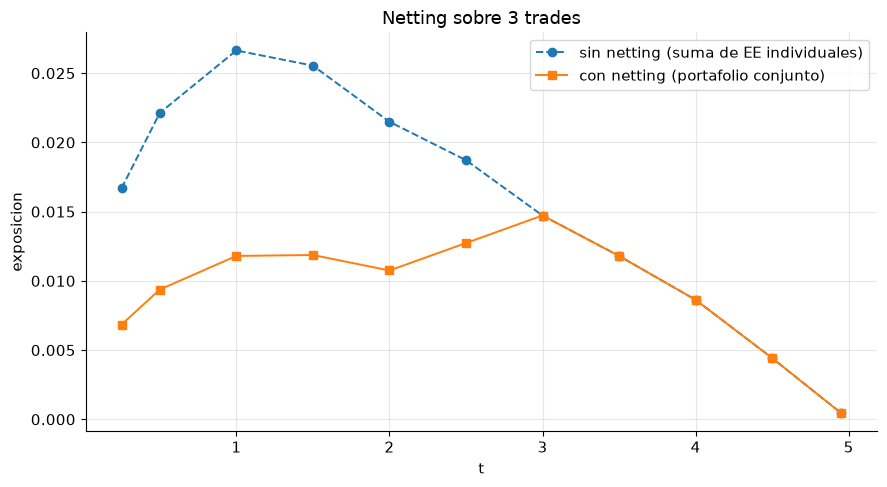

EE neteado <= suma de EE individuales, en toda la malla: True


In [3]:
EE1, EE2, EE3, EE_net = [], [], [], []
for t in check_times:
    r_t = short_rate(t, a, sigma, n_paths, rng)
    V1 = swap_value(t, r_t, K1, pt1, a, sigma)
    V2 = -swap_value(t, r_t, K2, pt2, a, sigma)  # direccion opuesta
    V3 = swap_value(t, r_t, K3, pt3, a, sigma)
    V_net = V1 + V2 + V3
    EE1.append(np.maximum(V1, 0.0).mean())
    EE2.append(np.maximum(V2, 0.0).mean())
    EE3.append(np.maximum(V3, 0.0).mean())
    EE_net.append(np.maximum(V_net, 0.0).mean())
EE1, EE2, EE3, EE_net = map(np.array, (EE1, EE2, EE3, EE_net))
EE_sum_no_netting = EE1 + EE2 + EE3

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(check_times, EE_sum_no_netting, "o--", label="sin netting (suma de EE individuales)")
ax.plot(check_times, EE_net, "s-", label="con netting (portafolio conjunto)")
ax.set_xlabel("t"); ax.set_ylabel("exposicion")
ax.set_title("Netting sobre 3 trades")
ax.legend(); fig.tight_layout(); plt.show()

netting_holds = np.all(EE_net <= EE_sum_no_netting + 1e-9)
print(f"EE neteado <= suma de EE individuales, en toda la malla: {netting_holds}")

## 2. CSA: threshold y margin period of risk (MPOR)

Bajo un CSA, el colateral NO reduce la exposición no colateralizada por una fracción fija.
La exposición residual — la que de verdad importa para CVA — es una cantidad distinta y
más sutil: el valor del neteado en el momento en que el colateral por fin podría reponerse
tras un default, comparado contra el colateral que quedó posteado en la ÚLTIMA fecha de
margining antes de ese default.

Formalmente, si $C_t=\max(V_t-H,0)$ es el colateral posteado con threshold $H$ en la fecha
de margining $t$, y $\Delta$ es el *margin period of risk* — el tiempo entre ese último
re-margining y el momento en que el default se resuelve y el colateral puede ajustarse —
la exposición residual relevante para CVA es

$$EE_{CSA}(t) = \mathbb{E}\big[(V_{t+\Delta} - C_t)^+\big]$$

Esta cantidad depende de la distribución CONJUNTA de $(V_t, V_{t+\Delta})$, y en particular
de la volatilidad del CAMBIO de valor durante la ventana $\Delta$ — no del nivel de $EE(t)$.
Dos posiciones con el mismo $EE(t)$ pero distinta volatilidad de $V_{t+\Delta}-V_t$ tienen
exposición residual distinta. Un proxy que solo mira el nivel de $EE(t)$ (como
`max(EE(t)-H,0)*factor`) no puede capturar esto y, peor, colapsa a cero cerca del
vencimiento simplemente porque $EE(t)$ cae por debajo del threshold — no porque el riesgo
real de la ventana MPOR haya desaparecido.

Para $\Delta$ usamos 10 días hábiles ($\approx 0.0397$ años), el valor estándar para
netting sets bilaterales no compensados centralmente bajo los requisitos de margen
BCBS-IOSCO y la metodología ISDA SIMM; para trades compensados centralmente el MPOR típico
es más corto, ~5 días hábiles (la CCP puede subastar o cubrir la posición más rápido).

Esto es factible con la infraestructura que ya tenemos: la tasa corta es un proceso de
Ornstein-Uhlenbeck (Hull-White 1F), que es Markoviano y Gaussiano, así que la ley
condicional de $x_{t+\Delta}$ dado $x_t$ es analítica:
$x_{t+\Delta}\,|\,x_t \sim \mathcal N\!\big(e^{-a\Delta}x_t,\ \tfrac{\sigma^2}{2a}(1-e^{-2a\Delta})\big)$.
Generamos $x_t$ como antes (reutilizando `ou`), y luego generamos $x_{t+\Delta}$ sumando
una innovación gaussiana condicional independiente — eso produce muestras conjuntas EXACTAS
del proceso OU sin construir un simulador paralelo. Con las trayectorias conjuntas
evaluamos el valor neteado del portafolio en $t$ y en $t+\Delta$ y aplicamos la fórmula de
arriba.

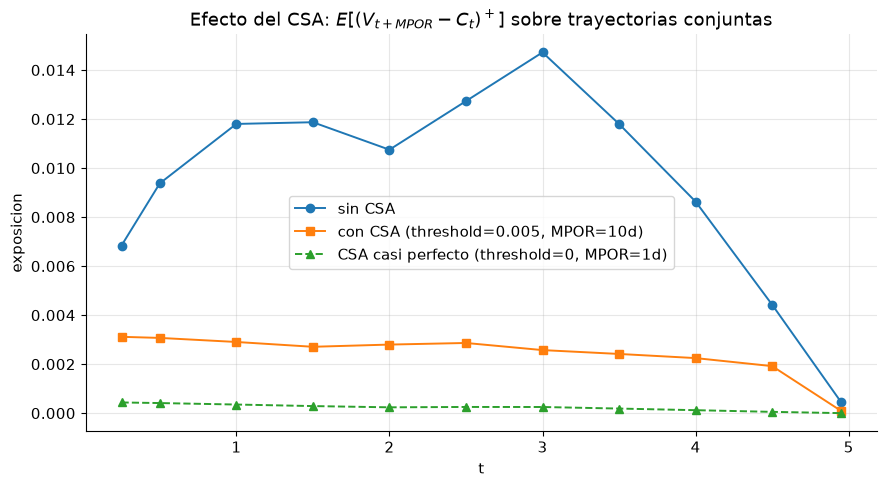

exposicion residual con CSA casi perfecto (threshold=0, MPOR=1d): max=4.36e-04
(no es cero: solo lo seria en el limite Delta->0 exacto -- ver la Seccion 3 para la tasa de convergencia)


In [4]:
def alpha_t(t, a, sigma):
    return sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2


def net_value_from_x(t, x, a, sigma):
    r_t = instantaneous_forward(t) + alpha_t(t, a, sigma) + x
    V1 = swap_value(t, r_t, K1, pt1, a, sigma)
    V2 = -swap_value(t, r_t, K2, pt2, a, sigma)  # direccion opuesta
    V3 = swap_value(t, r_t, K3, pt3, a, sigma)
    return V1 + V2 + V3


def simulate_joint_x(a, sigma, t, delta, n, rng):
    # Muestras conjuntas EXACTAS (x_t, x_{t+delta}) del proceso OU: x_t se genera
    # como siempre (via `ou`), y x_{t+delta} = e^{-a*delta} x_t + innovacion gaussiana
    # condicional independiente, con la varianza condicional analitica del OU
    # (Markov + Gaussiano => esto es una simulacion conjunta exacta, no una aproximacion).
    x_t = ou(a, sigma, t, n, rng)
    var_cond = sigma ** 2 / (2 * a) * (1.0 - np.exp(-2 * a * delta))
    x_tp = x_t * np.exp(-a * delta) + np.sqrt(var_cond) * rng.standard_normal(n)
    return x_t, x_tp


def csa_residual_profile(check_times, H, delta, a, sigma, n, rng):
    # E[(V_{t+delta} - C_t)^+] en cada t de check_times, con C_t = max(V_t - H, 0)
    # el colateral posteado en la ultima fecha de margining t.
    residual = []
    for t in check_times:
        x_t, x_tp = simulate_joint_x(a, sigma, t, delta, n, rng)
        V_t = net_value_from_x(t, x_t, a, sigma)
        V_tp = net_value_from_x(t + delta, x_tp, a, sigma)
        C_t = np.maximum(V_t - H, 0.0)
        residual.append(np.maximum(V_tp - C_t, 0.0).mean())
    return np.array(residual)


threshold = 0.005
mpor_bilateral = 10 / 252  # ~0.0397y, netting set bilateral no compensado centralmente
mpor_perfect = 1 / 252     # ~1 dia habil, aproxima el limite Delta->0 (ver Seccion 3)

EE_post_csa_realistic = csa_residual_profile(check_times, threshold, mpor_bilateral, a, sigma, n_paths, rng)
EE_post_csa_perfect = csa_residual_profile(check_times, 0.0, mpor_perfect, a, sigma, n_paths, rng)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(check_times, EE_net, "o-", label="sin CSA")
ax.plot(check_times, EE_post_csa_realistic, "s-",
        label=f"con CSA (threshold={threshold}, MPOR={mpor_bilateral * 252:.0f}d)")
ax.plot(check_times, EE_post_csa_perfect, "^--", label="CSA casi perfecto (threshold=0, MPOR=1d)")
ax.set_xlabel("t"); ax.set_ylabel("exposicion")
ax.set_title(r"Efecto del CSA: $E[(V_{t+MPOR}-C_t)^+]$ sobre trayectorias conjuntas")
ax.legend(); fig.tight_layout(); plt.show()

max_residual_perfect = np.max(EE_post_csa_perfect)
print(f"exposicion residual con CSA casi perfecto (threshold=0, MPOR=1d): max={max_residual_perfect:.2e}")
print("(no es cero: solo lo seria en el limite Delta->0 exacto -- ver la Seccion 3 "
      "para la tasa de convergencia)")

### Demo — CVA con y sin CSA

Usando la fórmula de integración de CVA de 11.2 (exposición esperada contra la densidad de
default), comparamos el CVA calculado con la exposición cruda del portafolio neteado contra
el CVA calculado con la exposición residual CORRECTA bajo CSA de la Sección 2
(`EE_post_csa_realistic`, threshold=0.005, MPOR=10 días hábiles) — cuantifica en dinero el
efecto de tener colateral, ahora con un modelo de exposición residual que refleja la
volatilidad de la ventana MPOR en vez de un factor arbitrario.

In [5]:
def cva_from_EE(EE_arr, check_times, lam=0.02, R=0.4, disc_curve=nelson_siegel_df):
    surv = np.exp(-lam * check_times)
    surv_prev = np.concatenate([[1.0], surv[:-1]])
    dP_default = surv_prev - surv
    return (1.0 - R) * np.sum(EE_arr * disc_curve(check_times) * dP_default)


cva_no_csa = cva_from_EE(EE_net, check_times)
cva_with_csa = cva_from_EE(EE_post_csa_realistic, check_times)
print(f"CVA sin CSA: {cva_no_csa:.6f}")
print(f"CVA con CSA (threshold={threshold}, MPOR>0): {cva_with_csa:.6f}")

CVA sin CSA: 0.000496
CVA con CSA (threshold=0.005, MPOR>0): 0.000123


## 3. Validación

Seis chequeos. El primero es el de la Sección 1, sin cambios. Los otros cinco atacan
directamente el modelo de exposición residual de la Sección 2 — $E[(V_{t+\Delta}-C_t)^+]$
sobre trayectorias conjuntas — y todos pueden fallar si hay un bug real (a diferencia de
los chequeos tautológicos que reemplazan):

1. **Netting** (Sección 1): se cumple en toda la malla.
2. **Límite $\Delta\to0$ con $H=0$**: al encoger $\Delta$, la exposición residual decrece
   monótonamente hacia cero. A diferencia del proxy anterior, aquí NO es cero por
   construcción algebraica — es una propiedad del límite que hay que verificar
   numéricamente, y con el modelo correcto SÍ puede fallar si hay un bug.
3. **Monotonía en $\Delta$**: a mayor margin period of risk, mayor exposición residual
   (más tiempo sin poder reponer colateral tras un movimiento adverso).
4. **Monotonía en $H$**: a mayor threshold, menos colateral se postea en la última fecha
   de margining, y por tanto mayor exposición residual.
5. **Escalamiento $\sqrt{\Delta}$**: con $H=0$, la exposición residual está gobernada por
   la volatilidad del cambio de valor sobre la ventana, que escala como $\sqrt{\Delta}$
   (desviación estándar de un incremento browniano) — verificamos la pendiente en log-log.
6. **Consistencia de la simulación conjunta**: la covarianza empírica de
   $(x_t, x_{t+\Delta})$ debe coincidir con la fórmula analítica del proceso OU,
   $\text{Cov}(x_t,x_{t+\Delta})=e^{-a\Delta}\text{Var}(x_t)$ — el control que atraparía
   un bug en cómo se generan las trayectorias conjuntas.

In [6]:
check1 = netting_holds
print(f"1. netting: EE(portafolio) <= suma de EE individuales: {check1}")

# --- 2 y 5: limite Delta->0 con H=0, y escalamiento sqrt(Delta) ---
t_probe = 2.5
deltas_shrink = np.array([0.00125, 0.0025, 0.005, 0.01, 0.02, 0.04, 0.08, 0.16, 0.32])
residual_shrink = []
for d in deltas_shrink:
    x_t, x_tp = simulate_joint_x(a, sigma, t_probe, d, n_paths, rng)
    V_t = net_value_from_x(t_probe, x_t, a, sigma)
    V_tp = net_value_from_x(t_probe + d, x_tp, a, sigma)
    C_t = np.maximum(V_t, 0.0)  # H=0
    residual_shrink.append(np.maximum(V_tp - C_t, 0.0).mean())
residual_shrink = np.array(residual_shrink)

shrinks_to_zero = np.all(np.diff(residual_shrink) > 0) and (residual_shrink[0] < 0.1 * residual_shrink[-1])
check2 = shrinks_to_zero
print(f"2. limite Delta->0 (H=0): exposicion crece con Delta y el valor mas pequeno "
      f"({residual_shrink[0]:.2e}, Delta={deltas_shrink[0]:.5f}) es < 10% del mas grande "
      f"({residual_shrink[-1]:.2e}, Delta={deltas_shrink[-1]:.2f}): {check2}")

slope, _ = np.polyfit(np.log(deltas_shrink), np.log(residual_shrink), 1)
check5 = abs(slope - 0.5) < 0.2
print(f"5. escalamiento sqrt(Delta) (H=0): pendiente log-log = {slope:.3f} (esperado ~0.5, "
      f"la desv. estandar de un incremento browniano escala como sqrt(Delta)): {check5}")

# --- 3: monotonia en Delta, con threshold realista ---
deltas_mono = np.array([1 / 252, 5 / 252, 10 / 252, 20 / 252, 40 / 252, 80 / 252])
residual_vs_delta = []
for d in deltas_mono:
    x_t, x_tp = simulate_joint_x(a, sigma, t_probe, d, n_paths, rng)
    V_t = net_value_from_x(t_probe, x_t, a, sigma)
    V_tp = net_value_from_x(t_probe + d, x_tp, a, sigma)
    C_t = np.maximum(V_t - threshold, 0.0)
    residual_vs_delta.append(np.maximum(V_tp - C_t, 0.0).mean())
residual_vs_delta = np.array(residual_vs_delta)

check3 = np.all(np.diff(residual_vs_delta) > 0)
print(f"3. monotonia en Delta (H={threshold}): {np.round(residual_vs_delta, 6)} -> creciente: {check3}")

# --- 4: monotonia en H, con MPOR realista ---
Hs = np.array([0.0, 0.003, 0.005, 0.01, 0.02])
residual_vs_H = []
for H in Hs:
    x_t, x_tp = simulate_joint_x(a, sigma, t_probe, mpor_bilateral, n_paths, rng)
    V_t = net_value_from_x(t_probe, x_t, a, sigma)
    V_tp = net_value_from_x(t_probe + mpor_bilateral, x_tp, a, sigma)
    C_t = np.maximum(V_t - H, 0.0)
    residual_vs_H.append(np.maximum(V_tp - C_t, 0.0).mean())
residual_vs_H = np.array(residual_vs_H)

check4 = np.all(np.diff(residual_vs_H) > 0)
print(f"4. monotonia en H (Delta={mpor_bilateral:.4f}): {np.round(residual_vs_H, 6)} -> creciente: {check4}")

# --- 6: consistencia de la simulacion conjunta contra la formula analitica del OU ---
x_t, x_tp = simulate_joint_x(a, sigma, t_probe, mpor_bilateral, n_paths, rng)
empirical_cov = np.cov(x_t, x_tp)[0, 1]
var_x_t = sigma ** 2 / (2 * a) * (1.0 - np.exp(-2 * a * t_probe))
analytical_cov = np.exp(-a * mpor_bilateral) * var_x_t
rel_err_cov = abs(empirical_cov - analytical_cov) / analytical_cov

check6 = rel_err_cov < 0.05
print(f"6. Cov(x_t, x_t+Delta) empirica={empirical_cov:.6e} vs analitica={analytical_cov:.6e} "
      f"(error relativo {rel_err_cov:.2%}): {check6}")

assert check1
assert check2
assert check3
assert check4
assert check5
assert check6
print("\nValidacion completa: 6/6 dentro de tolerancia.")

1. netting: EE(portafolio) <= suma de EE individuales: True
2. limite Delta->0 (H=0): exposicion crece con Delta y el valor mas pequeno (1.41e-04, Delta=0.00125) es < 10% del mas grande (2.96e-03, Delta=0.32): True
5. escalamiento sqrt(Delta) (H=0): pendiente log-log = 0.545 (esperado ~0.5, la desv. estandar de un incremento browniano escala como sqrt(Delta)): True


3. monotonia en Delta (H=0.005): [0.002687 0.002747 0.002854 0.003114 0.003656 0.004566] -> creciente: True
4. monotonia en H (Delta=0.0397): [0.000845 0.001954 0.002859 0.005076 0.008568] -> creciente: True
6. Cov(x_t, x_t+Delta) empirica=2.206122e-04 vs analitica=2.207608e-04 (error relativo 0.07%): True

Validacion completa: 6/6 dentro de tolerancia.


## Referencias

- Gregory, J. (2015). *The xVA Challenge*, cap. 9-10 (netting y colateral), cap. 6 (CSA),
  cap. 12 (margin period of risk y exposición bajo colateral imperfecto).
- ISDA (2013). *Standard Credit Support Annex*.
- Pykhtin, M. y Zhu, S. (2007). "A Guide to Modeling Counterparty Credit Risk", *GARP Risk
  Review* — exposición colateralizada como $E[(V_{t+\Delta}-C_t)^+]$ y su dependencia de
  la volatilidad del cambio de valor sobre la ventana MPOR (no del nivel de EE).
- Basel Committee on Banking Supervision / IOSCO (2015, rev. 2020). *Margin requirements
  for non-centrally cleared derivatives* — MPOR de 10 días hábiles para netting sets
  bilaterales bajo variation margin diario.
- ISDA (2016). *SIMM Methodology* — convenciones de MPOR para el cálculo de margen inicial
  en trades no compensados centralmente.